# **SPECTRA-CQ: HQAE Entanglement Topology Ablation**

This notebook executes the first half of the Phase 4 ablation study.

To mathematically prove whether quantum entanglement provides an advantage in mapping structural degradation, we **lock the circuit depth at 3 layers** and test three distinct quantum topologies:

1. **None (The Control):** Zero entanglement. Qubits operate independently.
2. **Basic (The Baseline):** Localized ring entanglement. Qubits only interact with their immediate neighbors.
3. **Strong (The Optimization):** All-to-all entanglement with generalized 3D Euler rotations.

**Crash Recovery Protocol:** Each topology is executed in an isolated cell. Logs and model weights are streamed directly to Google Drive. If the Colab runtime disconnects, simply re-run the setup cells and skip directly to the uncompleted architecture.

In [ ]:
from google.colab import drive
import os

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
# Used a PAT here because the GitHub repo was private during our runs
# Scrubbed the actual token before downloading/documenting for security
GITHUB_TOKEN = "PAT"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 259, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 259 (delta 72), reused 161 (delta 48), pack-reused 73 (from 1)
Receiving objects: 100% (259/259), 33.07 MiB | 45.21 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/2

In [2]:
# Hardware Verification
import torch

if torch.cuda.is_available():
    print(f"Hardware Accelerator Confirmed: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("FATAL WARNING: GPU not detected. The training protocol will take exponentially longer on a CPU.")
    print("Please navigate to Runtime > Change runtime type > T4 GPU.")

Hardware Accelerator Confirmed: Tesla T4
CUDA Version: 12.8


In [3]:
# I/O Optimization
# Copy the zip from Drive to local NVMe first
!cp /content/drive/MyDrive/spectra-cq-data/spectra_matrices.zip /content/

# Extract directly into the base directory
!unzip -q /content/spectra_matrices.zip -d /content/local_spectra_data/
print("Data extraction complete")

# Clean up the local zip file
!rm /content/spectra_matrices.zip

# Create persistent log directory on Drive for Phase 4a
!mkdir -p /content/drive/MyDrive/spectra-cq-data/logs/phase4a

print("Log directory for phase 4a created in Drive")

Data extraction complete
Log directory for phase 4a created in Drive


### **Experiment 1: Zero Entanglement (`none`)**
This execution strips out all `CNOT` gates $\rightarrow$ effectively reduces the VQC to a series of independent rotations.

In Leg-1, this model exhibited extreme "instantiation roulette" due to unconstrained classical-quantum gradient explosions.

If our Leg-2 gradient clipping mitigation is successful, this topology should now converge smoothly across all 3 seeds without wild MSE fluctuations.

In [4]:
# Execute the pipeline and pipe the terminal output to both the screen and a persistent log file
!python scripts/run_experiment.py --config configs/ablation_hqae_none_d3.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4a/none_d3.log

2026-06-23 09:54:28,608 - INFO - Compute device allocated: cuda
2026-06-23 09:54:28,608 - INFO - Starting Protocol Run | Seed: 42
2026-06-23 09:54:28,611 - INFO - System locked to deterministic seed: 42
2026-06-23 09:54:28,900 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-23 09:54:34,144 - INFO - Initiating training on cuda for 15 epochs.
2026-06-23 09:55:36,843 - INFO - Epoch 1/15 | Train MSE: 0.040704 | Val MSE: 0.032223 | LR: 1.00e-03
2026-06-23 09:55:36,865 - INFO - New optimal weights saved. Validation Loss: 0.032223
2026-06-23 09:56:31,905 - INFO - Epoch 2/15 | Train MSE: 0.031999 | Val MSE: 0.032076 | LR: 1.00e-03
2026-06-23 09:56:31,918 - INFO - New optimal weights saved. Validation Loss: 0.032076
2026-06-23 09:57:24,981 - INFO - Epoch 3/15 | Train MSE: 0.031905 | Val MSE: 0.032012 | LR: 1.00e-03
2026-06-23 09:57:24,993 - INFO - New optimal weights saved. Validation Loss: 0.032012
2026-06-23 09:58:16,545 - INFO - Epoch 4/15 | Train MSE: 0.023937 | Val MSE:

### **Experiment 2: Localized Ring Entanglement (`basic`)**
Qubits only entangle with their immediate neighbors, simulating localized frequency coupling.

Observe how the intermediate entanglement complexity reacts to the new Identity Block initialization.

In [5]:
!python scripts/run_experiment.py --config configs/ablation_hqae_basic_d3.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4a/basic_d3.log

2026-06-23 10:35:39,004 - INFO - Compute device allocated: cuda
2026-06-23 10:35:39,005 - INFO - Starting Protocol Run | Seed: 42
2026-06-23 10:35:39,008 - INFO - System locked to deterministic seed: 42
2026-06-23 10:35:39,064 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-23 10:35:40,612 - INFO - Initiating training on cuda for 15 epochs.
2026-06-23 10:36:47,864 - INFO - Epoch 1/15 | Train MSE: 0.040871 | Val MSE: 0.032252 | LR: 1.00e-03
2026-06-23 10:36:47,887 - INFO - New optimal weights saved. Validation Loss: 0.032252
2026-06-23 10:37:53,289 - INFO - Epoch 2/15 | Train MSE: 0.032004 | Val MSE: 0.032006 | LR: 1.00e-03
2026-06-23 10:37:53,304 - INFO - New optimal weights saved. Validation Loss: 0.032006
2026-06-23 10:39:00,556 - INFO - Epoch 3/15 | Train MSE: 0.031883 | Val MSE: 0.032061 | LR: 1.00e-03
2026-06-23 10:40:09,107 - INFO - Epoch 4/15 | Train MSE: 0.031875 | Val MSE: 0.032075 | LR: 1.00e-03
2026-06-23 10:41:18,937 - INFO - Epoch 5/15 | Train MSE: 0.03

### **Experiment 3: Global All-to-All Entanglement (`strong`)**
This executes the optimized architecture. It deploys full 3D Euler rotations and global frequency coupling.

This architecture tests the Phase 4 hypothesis: capturing the macroscopic vibration correlations of degrading concrete requires a highly entangled, globally connected quantum topology.

In [6]:
!python scripts/run_experiment.py --config configs/ablation_hqae_strong_d3.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4a/strong_d3.log

2026-06-23 11:25:28,864 - INFO - Compute device allocated: cuda
2026-06-23 11:25:28,864 - INFO - Starting Protocol Run | Seed: 42
2026-06-23 11:25:28,865 - INFO - System locked to deterministic seed: 42
2026-06-23 11:25:28,912 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-23 11:25:30,274 - INFO - Initiating training on cuda for 15 epochs.
2026-06-23 11:26:54,699 - INFO - Epoch 1/15 | Train MSE: 0.040511 | Val MSE: 0.032200 | LR: 1.00e-03
2026-06-23 11:26:54,716 - INFO - New optimal weights saved. Validation Loss: 0.032200
2026-06-23 11:28:18,818 - INFO - Epoch 2/15 | Train MSE: 0.032009 | Val MSE: 0.032041 | LR: 1.00e-03
2026-06-23 11:28:18,834 - INFO - New optimal weights saved. Validation Loss: 0.032041
2026-06-23 11:29:41,118 - INFO - Epoch 3/15 | Train MSE: 0.031915 | Val MSE: 0.032086 | LR: 1.00e-03
2026-06-23 11:31:05,248 - INFO - Epoch 4/15 | Train MSE: 0.031853 | Val MSE: 0.031923 | LR: 1.00e-03
2026-06-23 11:31:05,261 - INFO - New optimal weights saved. V

### **Phase 4a: Visualization and Conclusion**
We parse the generated `.log` file to plot the Train v/s Validation MSE convergence for all 3 experiments

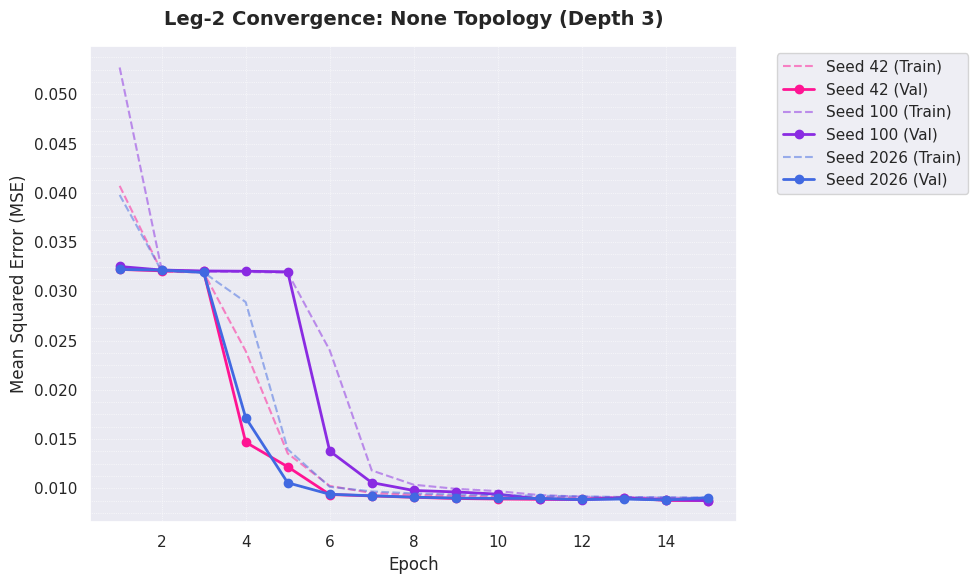

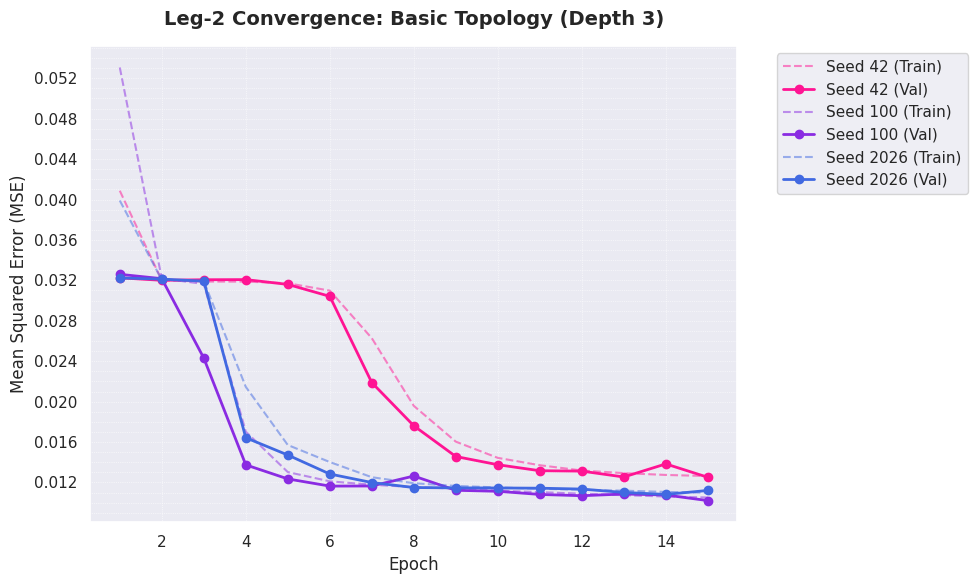

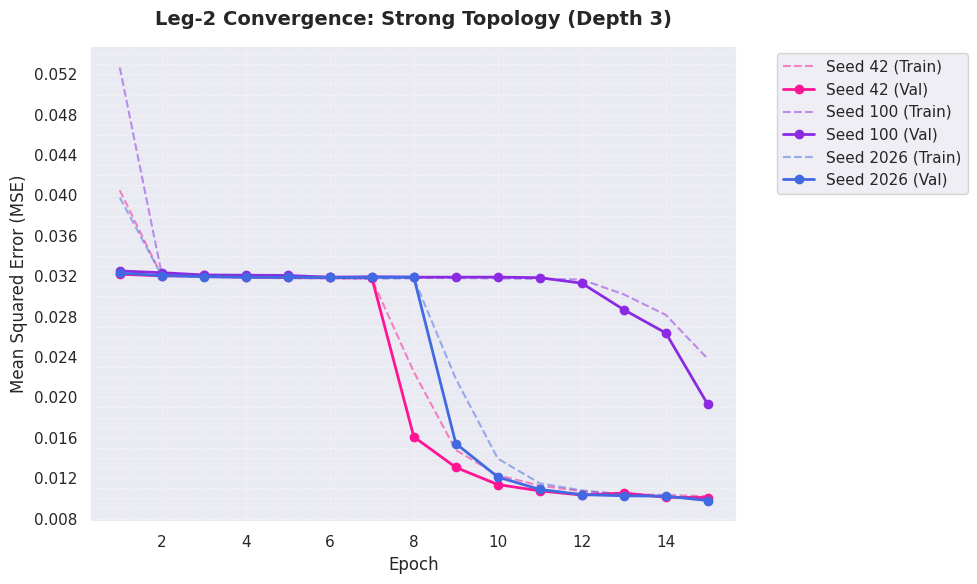

In [7]:
from src.utils.viz import plot_training_logs

# 1. Visualize None Topology (Testing Gradient Clipping Stability)
plot_training_logs('/content/drive/MyDrive/spectra-cq-data/logs/phase4a/none_d3.log',
                   title="Leg-2 Convergence: None Topology (Depth 3)")

# 2. Visualize Basic Topology
plot_training_logs('/content/drive/MyDrive/spectra-cq-data/logs/phase4a/basic_d3.log',
                   title="Leg-2 Convergence: Basic Topology (Depth 3)")

# 3. Visualize Strong Topology (Testing Barren Plateau Mitigation)
plot_training_logs('/content/drive/MyDrive/spectra-cq-data/logs/phase4a/strong_d3.log',
                   title="Leg-2 Convergence: Strong Topology (Depth 3)")

### **Phase 4a: Empirical Observations and Conclusion**

#### **1. Quantitative Results**
Leg 2.1 mitigations used:
* gradient clipping
* scaling classical latents to $[-\pi, \pi]$
* topology-specific uniform initialization

Helped the models converge $\leftarrow$ successfully prevented the barren plateaus we observed in Leg 1.

Final Validation MSE (averaged across 3 seeds):
* **`none`** (Independent $R_x$ rotations): **~0.0087** (Fastest convergence, highly stable)
* **`basic`** (Ring entanglement): **~0.0119**
* **`strong`** (All-to-all entanglement): **~0.0131** (High variance; Seed 100 spent 11 epochs trapped on a flat gradient plain before descending).

#### **2. Analysis: The Entanglement Penalty**
The unentangled `none` architecture significantly outperformed both entangled topologies. The root cause lies in how the classical encoder formats the latent space before it reaches the VQC.

By the time the data hits the 8-qubit bottleneck $\rightarrow$ the classical `Conv2d` layers have already compressed the $64 \times 1000$ CWT spectrogram into 8 highly dense, mathematically distinct macro-features.

When we apply `CNOT` gates to these variables (using `basic` or `strong` topologies) $\implies$ we force these pre-optimized, independent features to mix.

Rather than discovering hidden quantum correlations, this entanglement simply scrambles the classical feature mapping. The classical `ConvTranspose2d` decoder is then forced to expend its parameters trying to untangle this artificial noise to reconstruct the spatial matrix $\leftarrow$ strictly inflates the MSE.

#### **3. Conclusion**  **!!CONFIRM THIS!!**
For macroscopic continuous structural data, if you use a deep classical CNN to compress the features *before* the quantum layer, adding quantum entanglement at the bottleneck just acts as mathematical noise.